# Examen Práctico — Primer Parcial
## Tópicos de Big Data

**Instrucciones generales**

- Este notebook es tu entregable. Complétalo en orden, sin borrar los enunciados.
- Al final debes subir este archivo (`.ipynb`) al repositorio de GitHub del curso, en la carpeta correspondiente a tu nombre/usuario.
- Se evaluará tanto el código (que corra sin errores, de arriba hacia abajo) como tus interpretaciones escritas en las celdas de texto marcadas como *"Interpretación"*.
- Cada quien trabaja con **un dataset distinto**, asignado por la profesora. No copies celdas de un compañero con un dataset diferente: aunque las preguntas se parecen, los datos y las columnas no son las mismas.


## 0. Datos del alumno

Completa la siguiente celda con tus datos y el nombre del dataset que te fue asignado.

In [1]:
# --- COMPLETA CON TUS DATOS ---
NOMBRE = "Eduardo Emiliano Yépez Márquez"            # Tu nombre completo
MATRICULA = "82110"         # Tu matrícula o número de cuenta
DATASET_ASIGNADO = "desnutricion"  # Debe ser uno de: "alcohol", "migracion", "desnutricion", "pib", "homicidios"

print(f"Alumno: {NOMBRE}")
print(f"Matrícula: {MATRICULA}")
print(f"Dataset asignado: {DATASET_ASIGNADO}")


Alumno: Eduardo Emiliano Yépez Márquez
Matrícula: 82110
Dataset asignado: desnutricion


## 1. Configuración del entorno virtual (Visual Studio Code)

Antes de instalar librerías directamente en tu sistema, es una buena práctica crear un
**entorno virtual** exclusivo para este examen. Esto evita conflictos de versiones con
otros proyectos y hace que tu entorno de trabajo sea reproducible.

**Requisitos previos en VS Code:** ten instaladas las extensiones oficiales **"Python"**
y **"Jupyter"** (ambas de Microsoft), disponibles en la pestaña de Extensiones (ícono de
cuadritos en la barra lateral izquierda, o `Ctrl+Shift+X` / `Cmd+Shift+X`).

Abre una terminal **dentro de VS Code** (menú **Terminal → New Terminal**, o
`` Ctrl+ñ ``/`` Ctrl+` ``) y verifica que estés ubicado en la carpeta de tu repositorio
del curso (donde vas a guardar este notebook).

### Windows (PowerShell, terminal integrada de VS Code)

```powershell
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python -m venv .venv

# 2. Activar el entorno virtual
.venv\Scripts\Activate.ps1

# Si PowerShell bloquea la ejecución de scripts, ejecuta una sola vez:
#   Set-ExecutionPolicy -Scope CurrentUser RemoteSigned
# y vuelve a intentar activar el entorno.

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

### macOS / Linux (terminal integrada de VS Code, bash o zsh)

```bash
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python3 -m venv .venv

# 2. Activar el entorno virtual
source .venv/bin/activate

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

> **Nota:** usamos el nombre `.venv` (con punto) porque VS Code lo detecta automáticamente
> dentro de la carpeta del proyecto. Si usas Anaconda/Miniconda en lugar de `venv`, el
> equivalente es:
> ```bash
> conda create -n examen-bigdata python=3.11 pandas numpy ipykernel matplotlib requests -y
> conda activate examen-bigdata
> ```

### Seleccionar el entorno virtual como kernel en VS Code

A diferencia de Jupyter Notebook/Lab, en VS Code **no necesitas registrar el entorno
manualmente con `ipykernel install`**: basta con tener el paquete `ipykernel` instalado
en el entorno (ya quedó instalado en el paso anterior) y seleccionar ese entorno
directamente como kernel del notebook.

1. Abre este archivo `.ipynb` en VS Code.
2. En la esquina superior derecha del notebook, haz clic en el selector de kernel
   (dice algo como **"Select Kernel"** la primera vez).
3. Elige **"Python Environments..."** y de la lista selecciona el entorno `.venv`
   que acabas de crear (debe aparecer como algo como `.venv (Python 3.x.x)` con la
   ruta de tu proyecto).
4. Si no aparece en la lista, haz clic en **"Select Another Kernel" → "Python
   Environments..."** y usa **"Enter interpreter path..."** para localizar manualmente
   el ejecutable dentro de `.venv/bin/python` (macOS/Linux) o `.venv\Scripts\python.exe`
   (Windows).
5. Verifica que quedó bien seleccionado ejecutando la celda de abajo: debe mostrar una
   ruta que contenga la carpeta `.venv` (o el nombre de tu entorno de conda), y no la
   instalación global de Python.

In [2]:
import sys
print(sys.executable)
# Debe mostrar una ruta dentro de tu carpeta "venv" (o de tu entorno "examen-bigdata" si usas conda).
# Si muestra la ruta de tu instalacion global de Python, regresa al paso anterior
# y selecciona el kernel correcto antes de continuar.


c:\Users\emili\AppData\Local\Programs\Python\Python312\python.exe


## 2. Configuración y carga de datos

La siguiente celda **no se modifica**. Contiene la configuración de los 5 datasets
posibles del examen. A partir de tu variable `DATASET_ASIGNADO` de la celda anterior,
el notebook cargará automáticamente el dataset y los metadatos que te corresponden.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# --- NO MODIFICAR: configuración de los 5 datasets del examen ---
DATASETS = {
    "alcohol": {
        "csv": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "alcohol__consumers_past_12_months__pct__age_standardized__sex_both_sexes",
        "filtro_paises": "code",       # columna a usar para filtrar países reales vs. agregados
        "descripcion": "Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio",
        "unidad": "%",
    },
    "migracion": {
        "csv": "https://ourworldindata.org/grapher/migrant-populations.csv?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "meta": "https://ourworldindata.org/grapher/migrant-populations.metadata.json?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "valor_col": "immigrants_all",
        "filtro_paises": "owid_region",
        "descripcion": "Numero total de inmigrantes internacionales residiendo en el pais",
        "unidad": "personas",
    },
    "desnutricion": {
        "csv": "https://ourworldindata.org/grapher/number-undernourished.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/number-undernourished.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "_2_1_1_number_of_undernourished_people__000000000024001__value__006132__millions",
        "filtro_paises": "code",
        "descripcion": "Numero de personas subalimentadas (desnutricion)",
        "unidad": "personas",
    },
    "pib": {
        "csv": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "ny_gdp_pcap_kd",
        "filtro_paises": "code",
        "descripcion": "PIB per capita (dolares constantes de 2015)",
        "unidad": "USD",
    },
    "homicidios": {
        "csv": "https://ourworldindata.org/grapher/homicides-unodc.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/homicides-unodc.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "value__category_total__sex_total__age_total__unit_of_measurement_counts",
        "filtro_paises": "owid_region",
        "descripcion": "Numero de homicidios intencionales por anio",
        "unidad": "homicidios",
    },
}

assert DATASET_ASIGNADO in DATASETS, (
    "DATASET_ASIGNADO debe ser uno de: " + ", ".join(DATASETS.keys())
)

config = DATASETS[DATASET_ASIGNADO]
print(f"Cargando dataset: {DATASET_ASIGNADO}")
print(f"Descripcion: {config['descripcion']} ({config['unidad']})")


Cargando dataset: desnutricion
Descripcion: Numero de personas subalimentadas (desnutricion) (personas)


In [4]:
# Carga de datos y metadatos desde Our World in Data
df = pd.read_csv(
    config["csv"],
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)
metadata = requests.get(config["meta"]).json()

# Renombramos la columna de valor a "valor" para trabajar mas comodo durante todo el notebook
df = df.rename(columns={config["valor_col"]: "valor"})


In [5]:
df.head(25)

,entity,code,year,valor
0,Afghanistan,AFG,2001,9400000.0
1,Afghanistan,AFG,2002,9300000.0
2,Afghanistan,AFG,2003,8700000.0
3,Afghanistan,AFG,2004,8200000.0
4,Afghanistan,AFG,2005,7500000.0
5,Afghanistan,AFG,2006,6700000.0
6,Afghanistan,AFG,2007,5900000.0
7,Afghanistan,AFG,2008,5200000.0
8,Afghanistan,AFG,2009,4800000.0
9,Afghanistan,AFG,2010,5000000.0


## 3. Exploración inicial

Antes de responder las preguntas de análisis, explora el dataset: tipos de datos,
dimensiones, valores nulos y estadísticas descriptivas básicas.

In [6]:
# Forma del dataset (filas, columnas)
df.shape


(3544, 4)

In [7]:
# Tipos de datos e informacion general
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3544 entries, 0 to 3543
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   entity  3544 non-null   str    
 1   code    2758 non-null   str    
 2   year    3544 non-null   int64  
 3   valor   3544 non-null   float64
dtypes: float64(1), int64(1), str(2)
memory usage: 110.9 KB


In [8]:
# Estadisticas descriptivas de la columna 'valor'
df['valor'].describe()


count    3.544000e+03
mean     3.061574e+07
std      8.749230e+07
min      1.000000e+05
25%      3.000000e+05
50%      2.100000e+06
75%      9.925000e+06
max      8.252000e+08
Name: valor, dtype: float64

In [9]:
# Conteo de valores nulos por columna
df.isnull().sum()


entity      0
code      786
year        0
valor       0
dtype: int64

**Interpretación (2-3 líneas):** ¿qué observas sobre los valores nulos, el rango de
años y el tipo de variable con la que vas a trabajar?

*(Escribe aquí tu respuesta)*

## 4. Preguntas de análisis

A continuación responde las 10 preguntas. 

Cada una tiene una celda de código para su solución y, cuando aplica, 
una celda de texto para tu interpretación. Recuerda que tu
dataset (`DATASET_ASIGNADO`) puede o no tener la columna `owid_region`; revisa el
diccionario `DATASETS` de la celda de configuración para saber qué columna (`code` u
`owid_region`) te toca usar para distinguir países reales de agregados (continentes,
"World", grupos de ingreso, etc.).

### Pregunta 1 — Filtrado de países reales y ranking

Filtra el DataFrame para quedarte solo con países reales (usa la columna indicada en `config['filtro_paises']` de tu dataset). Guarda el resultado en una nueva variable `df_paises`. ¿Cuántos países distintos hay? Muestra los 10 países con mayor valor y los 10 con menor valor.

In [10]:
# Pregunta 1
df_paises = df.loc[df[config["filtro_paises"]].notnull()]
df_paises = df_paises.loc[df_paises["entity"] != "World"]

numero_paises = df_paises["entity"].nunique()
print("Países distintos:", n_paises)

top_mayor = df_paises.sort_values("valor", ascending=False).head(10)
top_menor = df_paises.sort_values("valor", ascending=True).head(10)




NameError: name 'n_paises' is not defined

In [ ]:
print("Top 10 menor valor")
top_menor[["entity", "year", "valor"]]

Top 10 menor valor


,entity,year,valor
3339,Vanuatu,2006,100000.0
3338,Vanuatu,2005,100000.0
3337,Vanuatu,2004,100000.0
3336,Vanuatu,2003,100000.0
3335,Vanuatu,2002,100000.0
64,Albania,2017,100000.0
63,Albania,2016,100000.0
62,Albania,2015,100000.0
61,Albania,2014,100000.0
60,Albania,2013,100000.0


In [ ]:
print("Top 10 mayor valor")
top_mayor[["entity", "year", "valor"]]

Top 10 mayor valor


,entity,year,valor
1341,India,2004,247000000.0
1342,India,2005,243900000.0
1340,India,2003,236800000.0
1343,India,2006,222200000.0
1339,India,2002,216300000.0
1358,India,2021,201900000.0
1344,India,2007,197200000.0
1338,India,2001,194900000.0
1359,India,2022,192000000.0
1357,India,2020,188400000.0


**Interpretación:**
Vanuautu es la población con menor desnutricon en los años registrados junto con albania, esto puede ser por la población pequeña que tiene. Por otra parte India tiene el mayor numero de personas desnutridas por la cantidad de  habitantes que tiene

### Pregunta 2 — Filtro por país y rango de años

Elige dos paises (Mexico y algún otro de tu interés) y filtra `df_paises` para mostrar únicamente su información dentro del rango de años disponible para ambos.

In [ ]:
# Pregunta 2
pais_1 = "Mexico"
pais_2 = "India"

anios_pais_1 = df_paises.loc[df_paises["entity"] == pais_1, "year"]
anios_pais_2 = df_paises.loc[df_paises["entity"] == pais_2, "year"]

anio_inicio = max(anios_pais_1.min(), anios_pais_2.min())
anio_fin = min(anios_pais_1.max(), anios_pais_2.max())

print(f"Rango de años en común: {anio_inicio} - {anio_fin}")

df_comparacion = df_paises.loc[
    df_paises["entity"].isin([pais_1, pais_2])
    & df_paises["year"].between(anio_inicio, anio_fin)
]

df_comparacion


Rango de años en común: 2001 - 2023


,entity,code,year,valor
1338,India,IND,2001,194900000.0
1339,India,IND,2002,216300000.0
1340,India,IND,2003,236800000.0
1341,India,IND,2004,247000000.0
1342,India,IND,2005,243900000.0
1343,India,IND,2006,222200000.0
1344,India,IND,2007,197200000.0
1345,India,IND,2008,185100000.0
1346,India,IND,2009,184300000.0
1347,India,IND,2010,181200000.0


### Pregunta 3 — Comparación entre países

Elige 5 países de tu interés (de distintos continentes) y compara el valor de tu indicador en el año más reciente disponible. ¿Cuál tiene el valor más alto y cuál el más bajo? Calcula la diferencia entre ambos.

In [ ]:
# Pregunta 3
paises_comparar = ["Japan", "Mexico", "Argentina", "Spain", "Nigeria"]

df_5paises = df_paises.loc[df_paises["entity"].isin(paises_comparar)]

anio_reciente = df_5paises["year"].max()
print("Año más reciente disponible:", anio_reciente)

df_5paises_anio = df_5paises.loc[df_5paises["year"] == anio_reciente, ["entity", "year", "valor"]]
df_5paises_anio
df_5paises_anio.sort_values("valor", ascending=False)

entidad_maximo = df_5paises_anio.loc[df_5paises_anio["valor"].idxmax(), "entity"]
entidad_minimo = df_5paises_anio.loc[df_5paises_anio["valor"].idxmin(), "entity"]

valor_maximo = df_5paises_anio["valor"].max()
valor_minimo = df_5paises_anio["valor"].min()

diferencia = valor_maximo - valor_minimo

print("País con el valor más alto:", entidad_maximo, "->", valor_maximo)
print("País con el valor más bajo:", entidad_minimo, "->", valor_minimo)
print("Diferencia:", diferencia)
for _, fila in df_5paises_anio.sort_values("valor", ascending=False).iterrows():
    print(f"{fila['entity']}: {fila['valor']}")



Año más reciente disponible: 2023
País con el valor más alto: Nigeria -> 45400000.0
País con el valor más bajo: Argentina -> 1500000.0
Diferencia: 43900000.0
Nigeria: 45400000.0
Mexico: 3500000.0
Argentina: 1500000.0


**Interpretación:**

Nigeria cuenta con el valor considerablemente más alto de desnutrición en comparación con los otros países, esto puede ser debido a que es un país de africa, presenta mayores conflictos regionales y tiene porblemos economicos. Por otra parte españa no aparece en los resultados, porque sus indices de desnutricion son nulos o casi nulos

### Pregunta 4 — Comparación entre grupos

Define dos grupos de países, el primero "latinoamerica" con Mexico, Colombia y Argentina, y el segundo "Asia" con China, Japon y Vietnam ( si algun pais no tiene informacion disponible, sustitúyelo por algún otro) y calcula el promedio de tu indicador en el año más reciente disponible.

In [ ]:
# Pregunta 4
# Pregunta 5
latinoamerica = ["Mexico", "Colombia", "Argentina"]
asia = ["China", "India", "Vietnam"]

def valor_mas_reciente(pais):
    datos_pais = df_paises.loc[df_paises["entity"] == pais]
    anio_max = datos_pais["year"].max()
    valor = datos_pais.loc[datos_pais["year"] == anio_max, "valor"].values[0]
    return anio_max, valor

for pais in latinoamerica + asia:
    anio, valor = valor_mas_reciente(pais)
    print(f"{pais}: {valor} (año {anio})")
valores_latam = [valor_mas_reciente(pais)[1] for pais in latinoamerica]
valores_asia = [valor_mas_reciente(pais)[1] for pais in asia]

promedio_latam = np.mean(valores_latam)
promedio_asia = np.mean(valores_asia)

print("Promedio Latinoamérica:", promedio_latam)
print("Promedio Asia:", promedio_asia)


Mexico: 3500000.0 (año 2023)
Colombia: 2000000.0 (año 2023)
Argentina: 1500000.0 (año 2023)
China: 38500000.0 (año 2009)
India: 172100000.0 (año 2023)
Vietnam: 5300000.0 (año 2023)
Promedio Latinoamérica: 2333333.3333333335
Promedio Asia: 71966666.66666667


**Interpretación:**

El promedio de Asia es mucho más grande por la población que tiene, latam tiene mucha menos destrunción que Asia

### Pregunta 5 — Tendencia temporal de un país

Para un país de tu elección, analiza cómo cambió tu indicador a lo largo del tiempo disponible en el dataset. ¿En qué año tuvo su valor máximo y en cuál el mínimo? ¿La tendencia general es creciente, decreciente o fluctuante?

Valor máximo: 1700000.0 en el año 2003
Valor mínimo: 1100000.0 en el año 2001


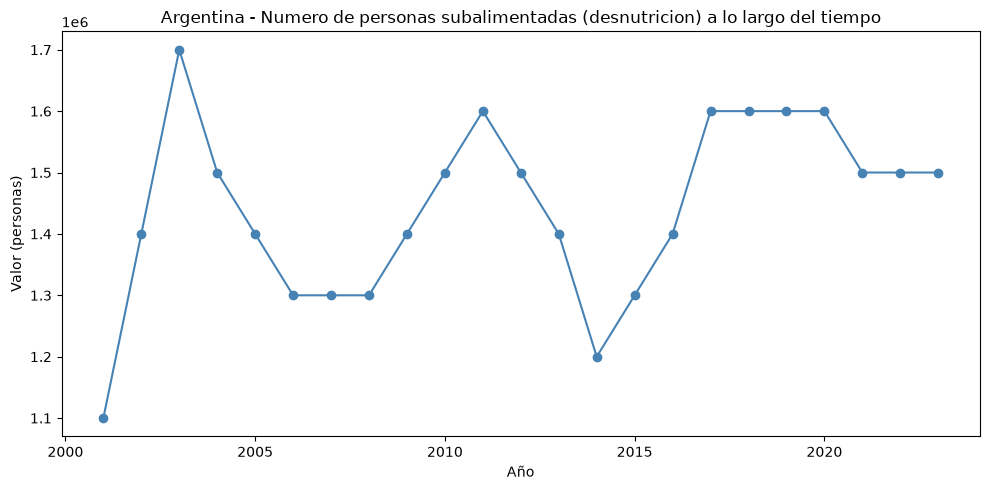

In [ ]:
# Pregunta 5
pais_elegido = "Argentina"

df_pais = df_paises.loc[df_paises["entity"] == pais_elegido].sort_values("year")

anio_maximo = df_pais.loc[df_pais["valor"].idxmax(), "year"]
valor_maximo = df_pais["valor"].max()

anio_minimo = df_pais.loc[df_pais["valor"].idxmin(), "year"]
valor_minimo = df_pais["valor"].min()

print(f"Valor máximo: {valor_maximo} en el año {anio_maximo}")
print(f"Valor mínimo: {valor_minimo} en el año {anio_minimo}")

plt.figure(figsize=(10, 5))
plt.plot(df_pais["year"], df_pais["valor"], marker="o", color="steelblue")

plt.xlabel("Año")
plt.ylabel(f"Valor ({config['unidad']})")
plt.title(f"{pais_elegido} - {config['descripcion']} a lo largo del tiempo")

plt.tight_layout()
plt.show()



**Interpretación:**

La tendencia de desnutrición en Argentina es fluctuante, varia bastante cada año, sin embargo desde los 2000 hasta los datos que se tienen, la desnutrición ha subido, alcanzando su minimo entre 2010 y 2015 y su maximo entre 2000 y 2005. Cada cierto tiempo tiene picos y vuelve a bajar.


### Pregunta 6 — Cambio porcentual

Para Mexico, calcula el cambio porcentual entre el primer y el último año con datos disponible. ¿presenta un incremento relativo o una caída? En tus palabras, ¿a qué crees que se debe el resultado? 

Valor en 2001: 2800000.0
Valor en 2023: 3500000.0
Cambio porcentual: 25.00%


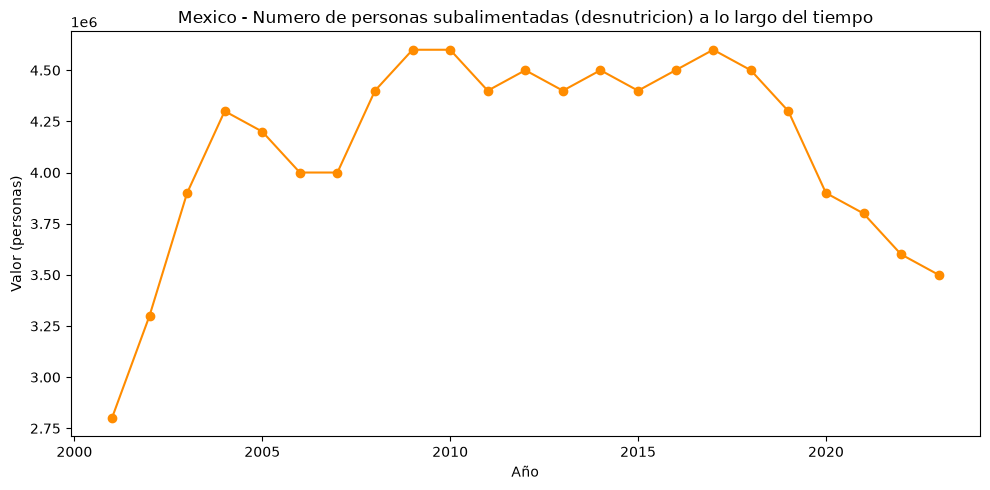

In [ ]:
# Pregunta 6
df_mexico = df_paises.loc[df_paises["entity"] == "Mexico"].sort_values("year")

anio_primero = df_mexico["year"].min()
anio_ultimo = df_mexico["year"].max()

valor_primero = df_mexico.loc[df_mexico["year"] == anio_primero, "valor"].values[0]
valor_ultimo = df_mexico.loc[df_mexico["year"] == anio_ultimo, "valor"].values[0]

cambio_porcentual = ((valor_ultimo - valor_primero) / valor_primero) * 100

print(f"Valor en {anio_primero}: {valor_primero}")
print(f"Valor en {anio_ultimo}: {valor_ultimo}")
print(f"Cambio porcentual: {cambio_porcentual:.2f}%")
plt.figure(figsize=(10, 5))
plt.plot(df_mexico["year"], df_mexico["valor"], marker="o", color="darkorange")

plt.xlabel("Año")
plt.ylabel(f"Valor ({config['unidad']})")
plt.title(f"Mexico - {config['descripcion']} a lo largo del tiempo")

plt.tight_layout()
plt.show()



**Interpretación:**

La desnutrición ha subido desde que se tienen los datos, su maximo fue entre 2005 y 2010, en los últimos años ha estado disminuyendo la nutrición con respecto a su pico, sigue aun por encima del punto inicial, esto puede ser debido a factores como econmía y la crecimiento de población, además la desnutrición en el país ha bajado en los últimos años por progrramas que se pudieron implementar.

### Pregunta 7 — Estadísticas descriptivas con NumPy

Usando NumPy (no `.describe()` de pandas), calcula la media, la mediana y la desviación estándar de tu columna valor entre todos los países reales, para el año más reciente disponible. 
Recuerda filtrar los `NaN` antes de calcular.

In [ ]:
# Pregunta 7
anio_reciente = df_paises["year"].max()

valores_anio = df_paises.loc[df_paises["year"] == anio_reciente, "valor"]
valores_anio = valores_anio.dropna().values

media = np.mean(valores_anio)
mediana = np.median(valores_anio)
desviacion_estandar = np.std(valores_anio, ddof=1)

print(f"Año más reciente: {anio_reciente}")
print(f"Media: {media:,.2f}")
print(f"Mediana: {mediana:,.2f}")
print(f"Desviación estándar: {desviacion_estandar:,.2f}")
print ("")
print("")


Año más reciente: 2023
Media: 5,884,761.90
Mediana: 1,600,000.00
Desviación estándar: 18,237,428.66



**Interpretación:**

El mundo parece tener bastante desnutrición, la media es mucho mayor que la mediana. Valores extremos tiran el prmedio mucho hacia arrriba.

### Pregunta 8 — Visualización de tendencia

Crea una gráfica de líneas con matplotlib que muestre la evolución de tu indicador a lo largo del tiempo para 3 países de tu elección, en una sola figura, con título, etiquetas de ejes y leyenda.

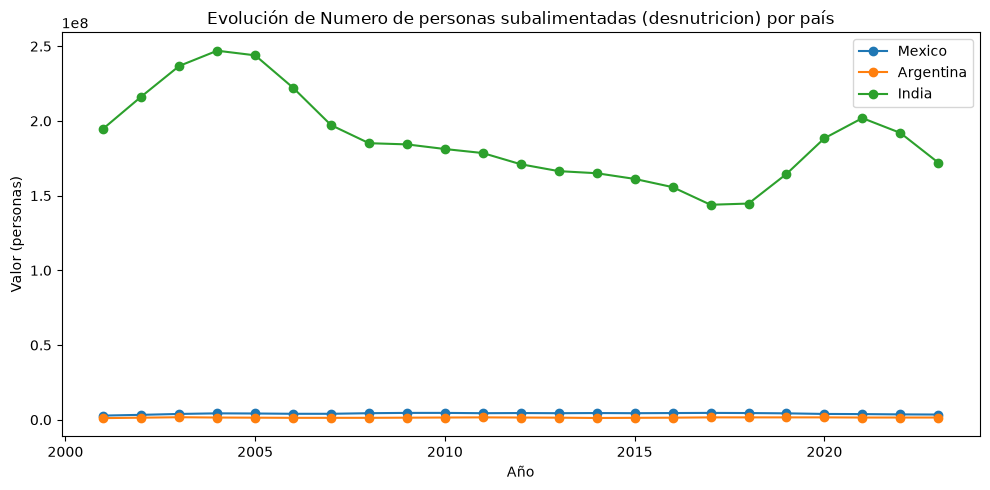

In [ ]:
# Pregunta 8
paises_grafica = ["Mexico", "Argentina", "India"]

plt.figure(figsize=(10, 5))

for pais in paises_grafica:
    df_pais = df_paises.loc[df_paises["entity"] == pais].sort_values("year")
    plt.plot(df_pais["year"], df_pais["valor"], marker="o", label=pais)

plt.xlabel("Año")
plt.ylabel(f"Valor ({config['unidad']})")
plt.title(f"Evolución de {config['descripcion']} por país")
plt.legend()

plt.tight_layout()
plt.show()


**Interpretación:**

India nuevamente parece tener una desnutrición bastante alta comparada con argentina y mexico, nuevemente esto es debido a la cantidad de su población grande que tiene. México y argentina tienen números muy parecudos y constantes. México tiene levemente mayor desnutrición que argentina.

### Pregunta 9 — Visualización integradora

Crea dos gráficas de barras (horizontales o verticales) con el Top 10 de países según tu indicador en la primera consulta el año de tu nacimiento, y en la segunda el año 2023, ordenados de mayor a menor.  Qué movimientos hubo en ambas gráficas?
Agrega título y etiquetas de ejes.

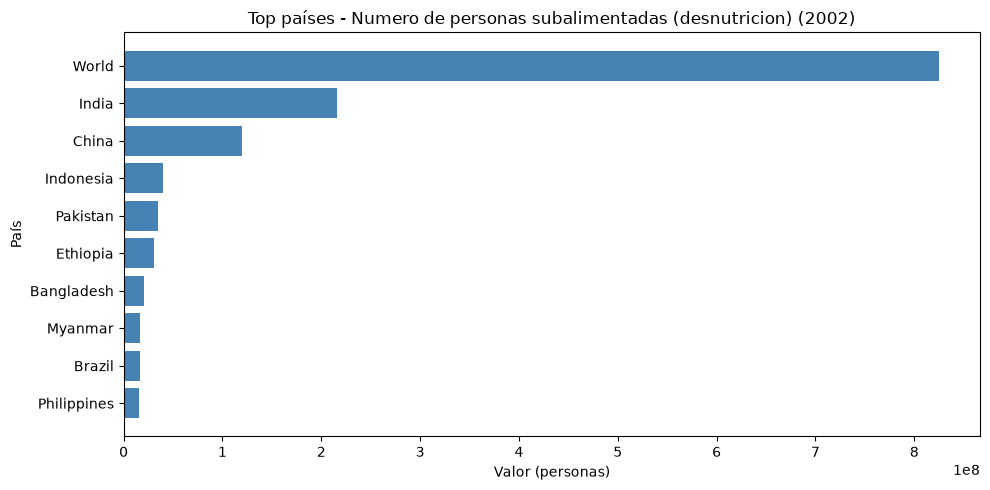

In [11]:
# Pregunta 9
# Tu codigo aqui
df_paises = df[df[config["filtro_paises"]].notnull()]

anio_consultado = 2002

top = (
    df_paises[df_paises['year'] == anio_consultado]
    .sort_values('valor', ascending=False)
    .head(10)
)
# Grafica de barras horizontales
plt.figure(figsize=(10, 5))
plt.barh(top['entity'], top['valor'], color='steelblue')

plt.xlabel(f"Valor ({config['unidad']})")
plt.ylabel("País")
plt.title(f"Top países - {config['descripcion']} ({anio_consultado})")

plt.gca().invert_yaxis()  # para que el país con el valor mas alto quede arriba
plt.tight_layout()
plt.show()
print ("")


**Interpretación:**

Los paises con mayor población y asiaticos presentan mayor desnutrición que el resto de los países en los datos, India es un claro ejemplo de esto. Sin embargo china a pesar de tener una población parecida que India tiene muchos menos números que esta.

## 5. Conclusión general


A lo largo de este examen, interprete que los países asiaticos presentan mayor desnutrición que loa otros países,el dataset tiene limitaciones como que no cuenta con todos los países y faltan los porcentajes de desnutrición que presenta cada país. Si tuviera más tiempo buscaria el porcentaje de dsnutrición de cada país para ver si es proporcional la desnutrición a su población. Los países asiaticos con mayor población presentan un mayor numero de desnutrición.




## 6. Entrega

1. Verifica que el notebook corra completo de arriba hacia abajo sin errores (`Kernel > Restart & Run All`).
2. Guarda el archivo con el nombre: `apellido_nombre_examen_parcial1.ipynb`.
3. Súbelo al repositorio de GitHub del curso, en una carpeta para este examen.
4. Comparte el link de tu repo y envia una copia del notebook por teams.
